# Oracle Accuracy vs. K

Reads one or more sweep TSVs produced by `scripts/grade.py --sweep --sweep-output` and plots accuracy vs. K.

**Generate the TSVs first:**
```bash
uv run python scripts/grade.py \
    --pred output/preds_char5_top500.txt output/preds_char6_top500.txt \
    --names char5 char6 \
    --answer data/madlad_multilang_clean_15k_optionB_kenlm/answer_valid.txt \
    --sweep --sweep-output output/sweep.tsv
```

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# ── Config ────────────────────────────────────────────────────────────────────
SWEEP_TSV = "../temp/fig/sweep.tsv"  # path to TSV from grade.py --sweep-output
MAX_K = None  # truncate x-axis (None = show all)
# ──────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(SWEEP_TSV, sep="\t")
if MAX_K:
    df = df[df["k"] <= MAX_K]
df["model"] = df["model"].str.replace("char", "n=", regex=False)
df.head()

,k,accuracy,correct,total,model
0,1,0.169202,89,526,n=2
1,2,0.307985,162,526,n=2
2,3,0.399240,210,526,n=2
3,4,0.467681,246,526,n=2
4,5,0.539924,284,526,n=2


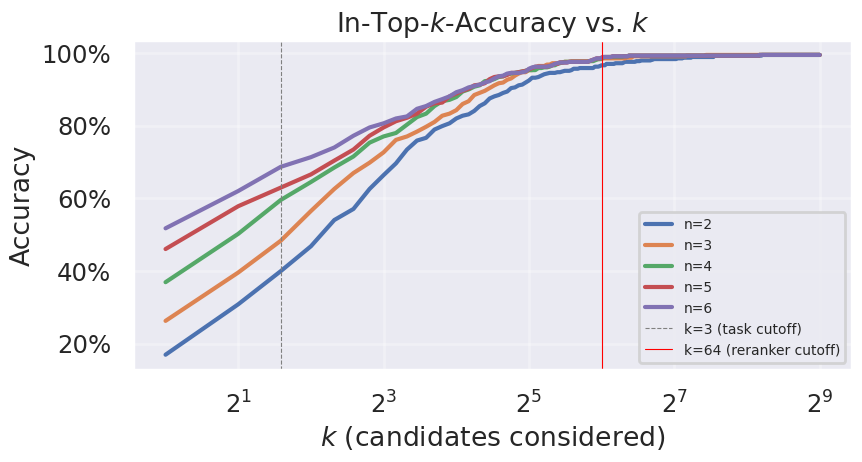

Saved to output/sweep_plot.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.set_theme()
sns.set_context("poster", font_scale=0.8)
sns.lineplot(data=df, x="k", y="accuracy", hue="model", ax=ax)

ax.axvline(x=3, color="grey", linestyle="--", linewidth=0.8, label="k=3 (task cutoff)")
ax.axvline(
    x=64, color="red", linestyle="-", linewidth=0.8, label="k=64 (reranker cutoff)"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("$k$ (candidates considered)")
ax.set_xscale("log", base=2)
ax.set_ylabel("Accuracy")
ax.set_title("In-Top-$k$-Accuracy vs. $k$")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/sweep_plot.png", dpi=150)
plt.show()
print("Saved to output/sweep_plot.png")

In [12]:
# Print accuracy at key cutoffs for each model
key_ks = [1, 3, 5, 10, 20, 32, 64, 128, 256, 512]
pivot = df[df["k"].isin(key_ks)].pivot(index="k", columns="model", values="accuracy")
pivot.index.name = "K"
pivot.columns.name = None
pivot.style.format("{:.2%}")

,n=2,n=3,n=4,n=5,n=6
K,,,,,
1,16.92%,26.24%,36.88%,46.01%,51.71%
3,39.92%,48.29%,59.51%,62.93%,68.63%
5,53.99%,62.55%,68.44%,70.34%,73.95%
10,73.38%,77.00%,80.23%,82.13%,82.51%
20,85.36%,88.97%,91.06%,91.25%,91.25%
32,92.40%,95.25%,95.25%,95.44%,95.63%
64,96.58%,98.29%,98.48%,98.67%,98.67%
128,98.29%,99.05%,99.24%,99.24%,99.24%
256,99.24%,99.43%,99.24%,99.24%,99.24%
